# DDSP Training

This notebook demonstrates the libraries in [https://github.com/magenta/ddsp/tree/master/ddsp/training](https://github.com/magenta/ddsp/tree/master/ddsp/training). It is a simple example, overfitting a single audio sample, for educational purposes.

_For a full training pipeline please use [ddsp/training/ddsp_run.py](https://github.com/magenta/ddsp/blob/main/ddsp/training/README.md#train-1) as in the [train_autoencoder.ipynb](https://github.com/magenta/ddsp/blob/main/ddsp/colab/demos/train_autoencoder.ipynb)_.



In [1]:
skip_training = True

In [2]:
# Install and import dependencies
# %tensorflow_version 2.x
# %pip install -qU ddsp

# Ignore a bunch of deprecation warnings
import warnings
warnings.filterwarnings("ignore")

import os
import time

# Point XLA to CUDA libdevice (from CUDA Toolkit)
os.environ.setdefault("XLA_FLAGS", "--xla_gpu_cuda_data_dir=/usr/local/cuda-12.4")

import ddsp
from ddsp.training import (data, decoders, encoders, models, preprocessing,
                           train_util, trainers)
try:
    from ddsp.colab.colab_utils import play, specplot, DEFAULT_SAMPLE_RATE
except ModuleNotFoundError:
    # Fallbacks for local (non-Colab) environments
    import numpy as np
    import matplotlib.pyplot as plt
    import librosa
    import librosa.display
    import IPython.display as ipd
    DEFAULT_SAMPLE_RATE = 16000

    def play(audio, sample_rate=DEFAULT_SAMPLE_RATE):
        y = audio.numpy().squeeze() if hasattr(audio, "numpy") else np.asarray(audio).squeeze()
        return ipd.display(ipd.Audio(y, rate=sample_rate))

    def specplot(audio, sample_rate=DEFAULT_SAMPLE_RATE, figsize=(10, 4)):
        y = audio.numpy().squeeze() if hasattr(audio, "numpy") else np.asarray(audio).squeeze()
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        plt.figure(figsize=figsize)
        librosa.display.specshow(D, sr=sample_rate, x_axis="time", y_axis="hz")
        plt.colorbar(format="%+2.0f dB")
        plt.tight_layout()

import gin
import matplotlib.pyplot as plt
import numpy as np
import tensorflow.compat.v2 as tf
import tensorflow_datasets as tfds

# Disable XLA JIT to avoid libdevice errors if toolkit is missing
tf.config.optimizer.set_jit(False)

sample_rate = DEFAULT_SAMPLE_RATE  # 16000

2026-01-29 11:15:35.758450: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 11:15:35.874921: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 11:15:36.333125: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-11.8/lib64:/usr/local/cuda-11.2/lib64:
2026-01-29 11:15:36.333228: W tensorflow/co

# Get a batch of data

2026-01-29 11:15:38.748651: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-29 11:15:38.778314: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-29 11:15:38.778371: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-29 11:15:38.779110: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other ope

64000


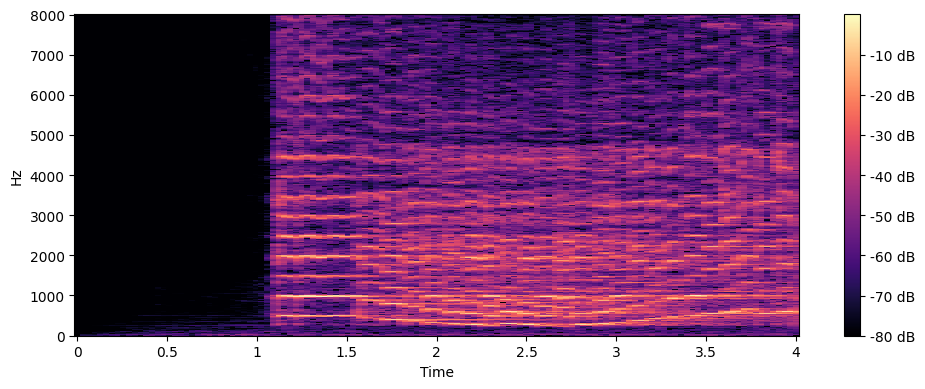

In [3]:
# Load examples from a TFRecord dataset (preferred for local data).
# If you only have WAVs in data/ddsp_data/wav, create TFRecords first, then point the pattern here.
tfrecord_pattern = "/home/namkhanh/Project/final_project/data/ddsp_data/violin_dataset.tfrecord*"

matches = tf.io.gfile.glob(tfrecord_pattern)
if not matches:
    raise FileNotFoundError(
        "No TFRecord files found. Create TFRecords from data/ddsp_data/wav and "
        "update tfrecord_pattern."
    )


data_provider = data.TFRecordProvider(file_pattern=tfrecord_pattern)
dataset = data_provider.get_batch(batch_size=1, shuffle=False).take(1).repeat()
batch = next(iter(dataset))
audio = batch['audio']


# Trim to reduce memory usage (e.g., 4 seconds)
max_samples = int(sample_rate * 4)
audio = audio[:, :max_samples]
n_samples = audio.shape[1]
print(n_samples)

specplot(audio)
play(audio)

# Get a distribution strategy


In [4]:
strategy = train_util.get_strategy()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


# Get model and trainer

## python

In [5]:
TIME_STEPS = 250

# Create Neural Networks.
preprocessor = preprocessing.F0LoudnessPreprocessor(time_steps=TIME_STEPS)

decoder = decoders.RnnFcDecoder(rnn_channels = 256,
                                rnn_type = 'gru',
                                ch = 256,
                                layers_per_stack = 1,
                                input_keys = ('ld_scaled', 'f0_scaled'),
                                output_splits = (('amps', 1),
                                                 ('harmonic_distribution', 30),
                                                 ('noise_magnitudes', 30)))

# Create Processors.
harmonic = ddsp.synths.Harmonic(n_samples=n_samples,
                                sample_rate=sample_rate,
                                name='harmonic')

noise = ddsp.synths.FilteredNoise(window_size=0,
                                  initial_bias=-10.0,
                                  name='noise')
add = ddsp.processors.Add(name='add')

# Create ProcessorGroup.
dag = [(harmonic, ['amps', 'harmonic_distribution', 'f0_hz']),
       (noise, ['noise_magnitudes']),
       (add, ['noise/signal', 'harmonic/signal'])]

processor_group = ddsp.processors.ProcessorGroup(dag=dag,
                                                 name='processor_group')


# Loss_functions
spectral_loss = ddsp.losses.SpectralLoss(loss_type='L1',
                                         mag_weight=1.0,
                                         logmag_weight=1.0)

with strategy.scope():
  # Put it together in a model.
  model = models.Autoencoder(preprocessor=preprocessor,
                             encoder=None,
                             decoder=decoder,
                             processor_group=processor_group,
                             losses=[spectral_loss])
  trainer = trainers.Trainer(model, strategy, learning_rate=1e-3)

## or [`gin`](https://github.com/google/gin-config)

In [6]:
gin_string = """
import ddsp
import ddsp.training

# Preprocessor
models.Autoencoder.preprocessor = @preprocessing.F0LoudnessPreprocessor()
preprocessing.F0LoudnessPreprocessor.time_steps = 1000


# Encoder
models.Autoencoder.encoder = None

# Decoder
models.Autoencoder.decoder = @decoders.RnnFcDecoder()
decoders.RnnFcDecoder.rnn_channels = 256
decoders.RnnFcDecoder.rnn_type = 'gru'
decoders.RnnFcDecoder.ch = 256
decoders.RnnFcDecoder.layers_per_stack = 1
decoders.RnnFcDecoder.input_keys = ('ld_scaled', 'f0_scaled')
decoders.RnnFcDecoder.output_splits = (('amps', 1),
                                       ('harmonic_distribution', 20),
                                       ('noise_magnitudes', 20))

# ProcessorGroup
models.Autoencoder.processor_group = @processors.ProcessorGroup()

processors.ProcessorGroup.dag = [
  (@harmonic/synths.Harmonic(),
    ['amps', 'harmonic_distribution', 'f0_hz']),
  (@noise/synths.FilteredNoise(),
    ['noise_magnitudes']),
  (@add/processors.Add(),
    ['noise/signal', 'harmonic/signal']),
]

# Harmonic Synthesizer
harmonic/synths.Harmonic.name = 'harmonic'
harmonic/synths.Harmonic.n_samples = 64000
harmonic/synths.Harmonic.scale_fn = @core.exp_sigmoid

# Filtered Noise Synthesizer
noise/synths.FilteredNoise.name = 'noise'
noise/synths.FilteredNoise.n_samples = 64000
noise/synths.FilteredNoise.window_size = 0
noise/synths.FilteredNoise.scale_fn = @core.exp_sigmoid
noise/synths.FilteredNoise.initial_bias = -10.0

# Add
add/processors.Add.name = 'add'

models.Autoencoder.losses = [
    @losses.SpectralLoss(),
]
losses.SpectralLoss.loss_type = 'L1'
losses.SpectralLoss.mag_weight = 1.0
losses.SpectralLoss.logmag_weight = 1.0
"""
print("Parsing gin config...")
with gin.unlock_config():
  gin.parse_config(gin_string)

print("Creating model and trainer...")
with strategy.scope():
  # Autoencoder arguments are filled by gin.
  model = ddsp.training.models.Autoencoder()
  trainer = trainers.Trainer(model, strategy, learning_rate=1e-4)
print("Starting training...")

Parsing gin config...
Creating model and trainer...
Starting training...


# Train

## Build model

In [7]:
# Build model, easiest to just run forward pass.
dataset = trainer.distribute_dataset(dataset)
trainer.build(next(iter(dataset)))

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
2026-01-29 11:15:46.254518: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-01-29 11:15:46.332903: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8907


Model: "autoencoder_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 f0_loudness_preprocessor_1   multiple                 0         
 (F0LoudnessPreprocessor)                                        
                                                                 
 rnn_fc_decoder_1 (RnnFcDeco  multiple                 801321    
 der)                                                            
                                                                 
 processor_group (ProcessorG  multiple                 0         
 roup)                                                           
                                                                 
 spectral_loss (SpectralLoss  multiple                 0         
 )                                                               
                                                                 
Total params: 801,321
Trainable params: 801,321
Non-t

## Train Loop

In [12]:
dataset_iter = iter(dataset)

target_loss = 5
max_steps = 3000
i = 0

while i < max_steps:
  losses = trainer.train_step(dataset_iter)
  total_loss = losses['total_loss']
  res_str = 'step: {}\t'.format(i)
  for k, v in losses.items():
    res_str += '{}: {:.4f}\t'.format(k, v)
  print(res_str)
  if total_loss <= target_loss:
    print('Stopping early: loss {:.4f} <= target {:.4f}'.format(total_loss, target_loss))
    break
  i += 1

step: 0	spectral_loss: 9.9780	total_loss: 9.9780	
step: 1	spectral_loss: 10.0045	total_loss: 10.0045	
step: 2	spectral_loss: 9.9039	total_loss: 9.9039	
step: 3	spectral_loss: 10.0377	total_loss: 10.0377	
step: 4	spectral_loss: 10.1526	total_loss: 10.1526	
step: 5	spectral_loss: 10.0220	total_loss: 10.0220	
step: 6	spectral_loss: 9.9004	total_loss: 9.9004	
step: 7	spectral_loss: 9.9250	total_loss: 9.9250	
step: 8	spectral_loss: 9.8837	total_loss: 9.8837	
step: 9	spectral_loss: 9.8739	total_loss: 9.8739	
step: 10	spectral_loss: 9.8708	total_loss: 9.8708	
step: 11	spectral_loss: 9.8522	total_loss: 9.8522	
step: 12	spectral_loss: 9.9583	total_loss: 9.9583	
step: 13	spectral_loss: 9.9850	total_loss: 9.9850	
step: 14	spectral_loss: 9.8622	total_loss: 9.8622	
step: 15	spectral_loss: 10.0411	total_loss: 10.0411	
step: 16	spectral_loss: 10.2218	total_loss: 10.2218	
step: 17	spectral_loss: 10.0573	total_loss: 10.0573	
step: 18	spectral_loss: 9.8343	total_loss: 9.8343	
step: 19	spectral_loss: 10.

# Analyze results

In [13]:
# Run a batch of predictions.
start_time = time.time()
audio = next(dataset_iter)
controls =  model(audio)
audio_gen = model.get_audio_from_outputs(controls)
print('Prediction took %.1f seconds' % (time.time() - start_time))

Prediction took 0.3 seconds


Original Audio


Resynthesized Audio


Filtered Noise Audio


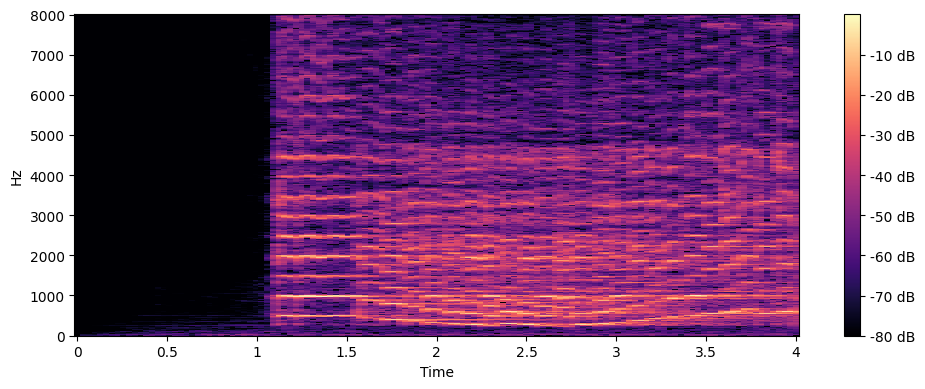

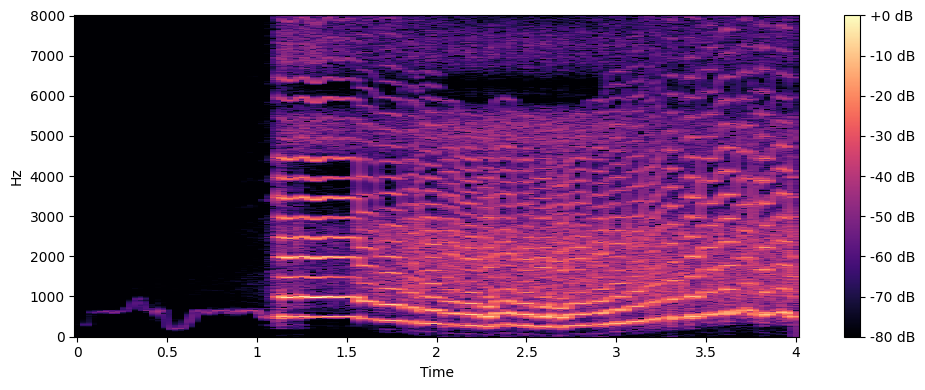

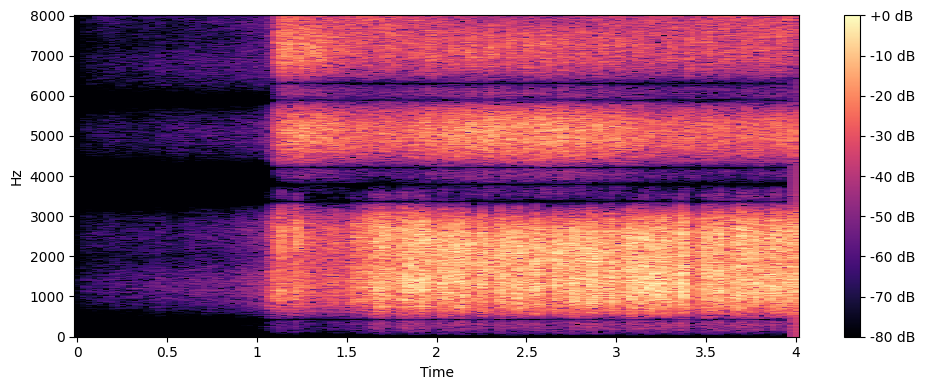

In [14]:
print('Original Audio')
play(audio['audio'])
print('Resynthesized Audio')
play(audio_gen)
print('Filtered Noise Audio')
audio_noise = controls['noise']['signal']
play(audio_noise)

specplot(audio['audio'])
specplot(audio_gen)
specplot(audio_noise)

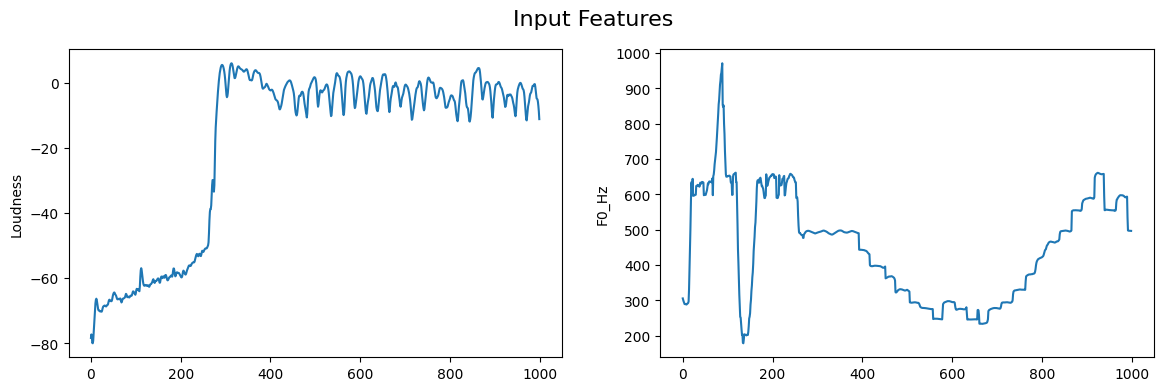

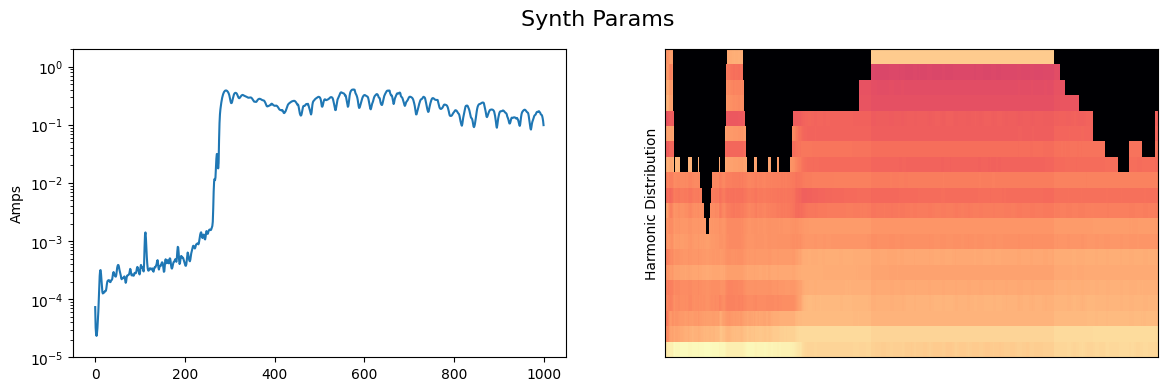

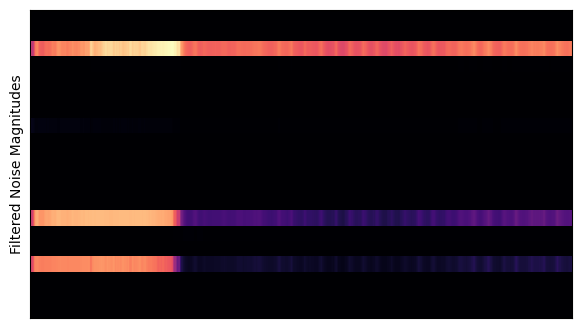

In [11]:
batch_idx = 0
get = lambda key: ddsp.core.nested_lookup(key, controls)[batch_idx]

amps = get('harmonic/controls/amplitudes')
harmonic_distribution = get('harmonic/controls/harmonic_distribution')
noise_magnitudes = get('noise/controls/magnitudes')
f0_hz = get('f0_hz')
loudness = get('loudness_db')

audio_noise = get('noise/signal')

f, ax = plt.subplots(1, 2, figsize=(14, 4))
f.suptitle('Input Features', fontsize=16)
ax[0].plot(loudness)
ax[0].set_ylabel('Loudness')
ax[1].plot(f0_hz)
ax[1].set_ylabel('F0_Hz')

f, ax = plt.subplots(1, 2, figsize=(14, 4))
f.suptitle('Synth Params', fontsize=16)
ax[0].semilogy(amps)
ax[0].set_ylabel('Amps')
ax[0].set_ylim(1e-5, 2)
# ax[0].semilogy(harmonic_distribution)
ax[1].matshow(np.rot90(np.log10(harmonic_distribution + 1e-6)),
              cmap=plt.cm.magma,
              aspect='auto')
ax[1].set_ylabel('Harmonic Distribution')
ax[1].set_xticks([])
_ = ax[1].set_yticks([])

f, ax = plt.subplots(1, 1, figsize=(7, 4))
# f.suptitle('Filtered Noise Params', fontsize=16)
ax.matshow(np.rot90(np.log10(noise_magnitudes + 1e-6)),
           cmap=plt.cm.magma,
           aspect='auto')
ax.set_ylabel('Filtered Noise Magnitudes')
ax.set_xticks([])
_ = ax.set_yticks([])
